In [1]:
import pandas as pd
import geopandas as gpd
from shapely.wkt import loads

In [2]:
# 1. Chargement du dataset 
missing_values = ["N/a", "N/A", "na", "NA", "None", "", "Nsp", "Nsp", "nan", "NaN"]
df = pd.read_csv("Formations sanitaires  Publiques.csv", na_values=missing_values)

In [3]:
df.head()

,FID,region_nom_bdd,prefecture_nom_bdd,commune_nom_bdd,canton_nom_bdd,nom_localite,nom_fs,etab_adr,ouverture_jour,annee,etablissement_type,secteur,ministere_tutelle,services_proposes,geometry
0,_mview_sant_etablissements_sante.fid--7972e7e3...,Maritime,Vo,Vo 3,Dzrékpo,Dzrékpo,USP Dzrekpo,NaN,NaN,NaN,USP 1,Public,NaN,NaN,POINT (1.5693608209053378 6.471152959951261)
1,_mview_sant_etablissements_sante.fid--7972e7e3...,Kara,Kéran,Kéran 3,Nadoba,Pimini,USP Pimini,NaN,NaN,NaN,USP 1,Public,NaN,{Traitement},POINT (1.0580971405217465 10.110191448382826)
2,_mview_sant_etablissements_sante.fid--7972e7e3...,Maritime,Agoè-Nyivé,Agoè-Nyivé 5,Sanguera,Agoe nyive 5,CMS Sanguera,NaN,"{Lundi,Mardi,Mercredi,Jeudi,Vendredi,Samedi,Di...",1945.0,USP 2,Public,MSHPAUS,"{Diagnostic ou demande d examen de crachats,Tr...",POINT (1.1133503004084486 6.229676858665188)
3,_mview_sant_etablissements_sante.fid--7972e7e3...,Maritime,Golfe,Golfe 6,Baguida,Golfe6/baguida,USP Devego,NaN,"{Lundi,Mardi,Mercredi,Jeudi,Vendredi,Samedi,Di...",2008.0,USP 2,Public,MSHPAUS,"{Diagnostic ou demande d examen de crachats,Di...",POINT (1.3435256114882244 6.19473540809048)
4,_mview_sant_etablissements_sante.fid--7972e7e3...,Maritime,Lacs,Lacs 1,Aného,Lacs,Polyclinique Mere-Enfant d'Aneho,BP 121,"{Dimanche,Samedi,Vendredi,Jeudi,Mercredi,Mardi...",2007.0,Hopital 1,Public,MSHPAUS,"{Diagnostic ou demande d examen de crachats,Tr...",POINT (1.5948030280562 6.229670357709534)


In [4]:
# 2. Conversion de la colonne geometry (WKT) en un vrai GeoDataFrame
df['geometry'] = df['geometry'].apply(loads)
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")

In [5]:
gdf.head()

,FID,region_nom_bdd,prefecture_nom_bdd,commune_nom_bdd,canton_nom_bdd,nom_localite,nom_fs,etab_adr,ouverture_jour,annee,etablissement_type,secteur,ministere_tutelle,services_proposes,geometry
0,_mview_sant_etablissements_sante.fid--7972e7e3...,Maritime,Vo,Vo 3,Dzrékpo,Dzrékpo,USP Dzrekpo,NaN,NaN,NaN,USP 1,Public,NaN,NaN,POINT (1.56936 6.47115)
1,_mview_sant_etablissements_sante.fid--7972e7e3...,Kara,Kéran,Kéran 3,Nadoba,Pimini,USP Pimini,NaN,NaN,NaN,USP 1,Public,NaN,{Traitement},POINT (1.0581 10.11019)
2,_mview_sant_etablissements_sante.fid--7972e7e3...,Maritime,Agoè-Nyivé,Agoè-Nyivé 5,Sanguera,Agoe nyive 5,CMS Sanguera,NaN,"{Lundi,Mardi,Mercredi,Jeudi,Vendredi,Samedi,Di...",1945.0,USP 2,Public,MSHPAUS,"{Diagnostic ou demande d examen de crachats,Tr...",POINT (1.11335 6.22968)
3,_mview_sant_etablissements_sante.fid--7972e7e3...,Maritime,Golfe,Golfe 6,Baguida,Golfe6/baguida,USP Devego,NaN,"{Lundi,Mardi,Mercredi,Jeudi,Vendredi,Samedi,Di...",2008.0,USP 2,Public,MSHPAUS,"{Diagnostic ou demande d examen de crachats,Di...",POINT (1.34353 6.19474)
4,_mview_sant_etablissements_sante.fid--7972e7e3...,Maritime,Lacs,Lacs 1,Aného,Lacs,Polyclinique Mere-Enfant d'Aneho,BP 121,"{Dimanche,Samedi,Vendredi,Jeudi,Mercredi,Mardi...",2007.0,Hopital 1,Public,MSHPAUS,"{Diagnostic ou demande d examen de crachats,Tr...",POINT (1.5948 6.22967)


### Informations Générales

In [6]:
print(f"Nombre de formations sanitaires répertoriées : {gdf.shape[0]}")

Nombre de formations sanitaires répertoriées : 792


In [7]:
print(f"Nombre de colonnes : {gdf.shape[1]}\n")

Nombre de colonnes : 15



In [8]:
print(gdf.info())

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 792 entries, 0 to 791
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   FID                 792 non-null    str     
 1   region_nom_bdd      792 non-null    str     
 2   prefecture_nom_bdd  792 non-null    str     
 3   commune_nom_bdd     792 non-null    str     
 4   canton_nom_bdd      792 non-null    str     
 5   nom_localite        792 non-null    str     
 6   nom_fs              792 non-null    str     
 7   etab_adr            141 non-null    str     
 8   ouverture_jour      755 non-null    str     
 9   annee               675 non-null    float64 
 10  etablissement_type  792 non-null    str     
 11  secteur             792 non-null    str     
 12  ministere_tutelle   767 non-null    str     
 13  services_proposes   781 non-null    str     
 14  geometry            792 non-null    geometry
dtypes: float64(1), geometry(1), str(

### Taux de valeurs manquantes par colonne

In [9]:
missing_pct = (gdf.isnull().sum() / len(gdf)) * 100
print(missing_pct.sort_values(ascending=False))

etab_adr              82.196970
annee                 14.772727
ouverture_jour         4.671717
ministere_tutelle      3.156566
services_proposes      1.388889
region_nom_bdd         0.000000
FID                    0.000000
nom_fs                 0.000000
nom_localite           0.000000
canton_nom_bdd         0.000000
commune_nom_bdd        0.000000
prefecture_nom_bdd     0.000000
etablissement_type     0.000000
secteur                0.000000
geometry               0.000000
dtype: float64


In [10]:
# conversion du type de la colonne annee en numeric
gdf['annee']=gdf['annee'].astype('Int64')

### Nettoyage de la colonne services_proposes

In [11]:
def clean_services(val):
    if pd.isna(val):
        return []
    # Enlever les accolades
    cleaned = val.strip("{}")
    if not cleaned:
        return []
    return [s.strip() for s in cleaned.split(',')]

In [12]:
gdf['services_nettoyes'] = gdf['services_proposes'].apply(clean_services)

### Vérification des types et des manquants ajustés

In [13]:
gdf[['annee', 'services_nettoyes', 'etablissement_type']].head()

,annee,services_nettoyes,etablissement_type
0,<NA>,[],USP 1
1,<NA>,[Traitement],USP 1
2,1945,"[Diagnostic ou demande d examen de crachats, T...",USP 2
3,2008,"[Diagnostic ou demande d examen de crachats, D...",USP 2
4,2007,"[Diagnostic ou demande d examen de crachats, T...",Hopital 1


In [14]:
print(gdf.isnull().sum())

FID                     0
region_nom_bdd          0
prefecture_nom_bdd      0
commune_nom_bdd         0
canton_nom_bdd          0
nom_localite            0
nom_fs                  0
etab_adr              651
ouverture_jour         37
annee                 117
etablissement_type      0
secteur                 0
ministere_tutelle      25
services_proposes      11
geometry                0
services_nettoyes       0
dtype: int64


In [15]:
columns_drop =['ministere_tutelle', 'secteur', 'FID','etab_adr', 'ouverture_jour']
gdf.drop(columns = columns_drop, inplace=True)
gdf.columns

Index(['region_nom_bdd', 'prefecture_nom_bdd', 'commune_nom_bdd',
       'canton_nom_bdd', 'nom_localite', 'nom_fs', 'annee',
       'etablissement_type', 'services_proposes', 'geometry',
       'services_nettoyes'],
      dtype='str')

In [16]:
gdf['services_proposes'].nunique()

694

### Analyse exploratoire 

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [18]:
print("--- Répartition par Type d'Établissement ---")
print(gdf['etablissement_type'].value_counts())

--- Répartition par Type d'Établissement ---
etablissement_type
USP 1         573
USP 2         133
Infirmerie     39
Hopital 1      22
Hopital 2      16
CHR             6
CHU             3
Name: count, dtype: int64


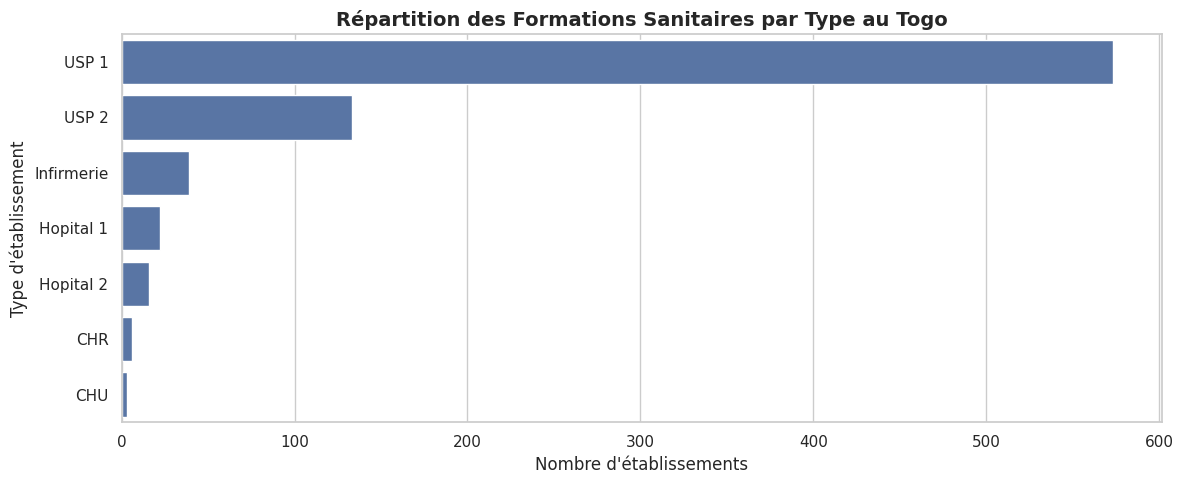

In [19]:
# le paysage des types d'établissements au Togo ?
plt.figure(figsize=(12, 5))
sns.countplot(
    data=gdf, 
    y='etablissement_type', 
    order=gdf['etablissement_type'].value_counts().index
)
plt.title("Répartition des Formations Sanitaires par Type au Togo", fontsize=14, weight='bold')
plt.xlabel("Nombre d'établissements")
plt.ylabel("Type d'établissement")
plt.tight_layout()
plt.show()

In [20]:
print("--- Répartition des formations sanitaire par region ---")
print(gdf['region_nom_bdd'].value_counts())

--- Répartition des formations sanitaire par region ---
region_nom_bdd
Maritime    223
Plateaux    222
Kara        147
Centrale    101
Savanes      99
Name: count, dtype: int64


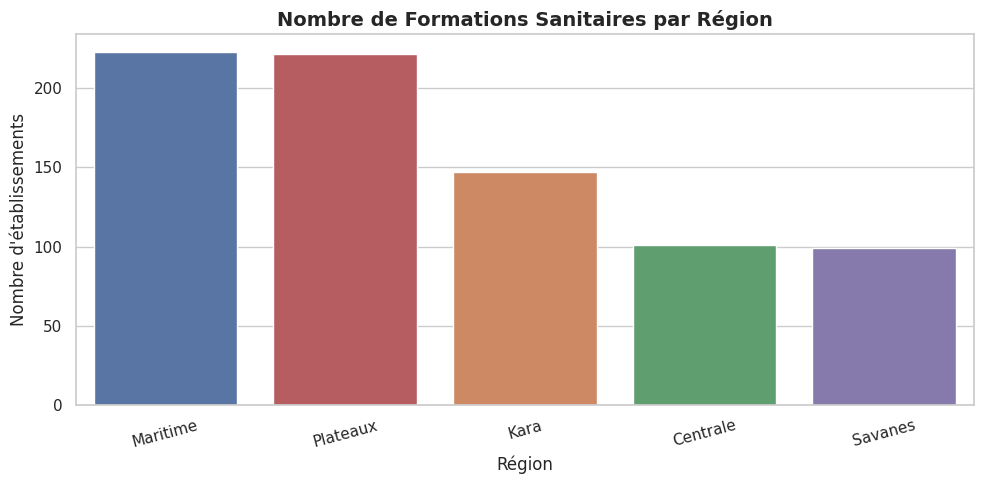

In [21]:
# Comment les structures sont-elles réparties par Région ?
plt.figure(figsize=(10, 5))
sns.countplot(
    data=gdf, 
    x='region_nom_bdd', 
    order=gdf['region_nom_bdd'].value_counts().index,
    hue='region_nom_bdd' 
)
plt.title("Nombre de Formations Sanitaires par Région", fontsize=14, weight='bold')
plt.xlabel("Région")
plt.ylabel("Nombre d'établissements")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [22]:
print("--- Repartition des formations sanitaire par prefecture ---")
print(gdf['prefecture_nom_bdd'].value_counts())

--- Repartition des formations sanitaire par prefecture ---
prefecture_nom_bdd
Golfe             68
Kozah             50
Zio               40
Tône              35
Tchaoudjo         34
Kloto             29
Agou              28
Amou              28
Lacs              27
Haho              26
Yoto              23
Blitta            22
Sotouboua         21
Doufelgou         21
Wawa              21
Vo                20
Bassar            20
Ogou              20
Est-Mono          19
Tandjoaré         18
Tchamba           17
Binah             17
Avé               17
Dankpen           16
Bas-Mono          16
Kéran             15
Oti               15
Agoè-Nyivé        12
Akébou            12
Oti-Sud           12
Kpélé             11
Anié              11
Danyi             11
Kpendjal-Ouest    10
Assoli             8
Mô                 7
Moyen-Mono         6
Cinkassé           5
Kpendjal           4
Name: count, dtype: int64


In [23]:
# le Top 5 prefecture ayant les plus de formations sanitaires
top_5_pref = gdf['prefecture_nom_bdd'].value_counts().head(5)
print(top_5_pref)


prefecture_nom_bdd
Golfe        68
Kozah        50
Zio          40
Tône         35
Tchaoudjo    34
Name: count, dtype: int64


In [24]:
# Filtrer le dataset pour ne garder que ce Top 5
df_top5 = gdf[gdf['prefecture_nom_bdd'].isin(top_5_pref.index)]
top5_cross = pd.crosstab(df_top5['prefecture_nom_bdd'], df_top5['etablissement_type']).loc[top_5_pref.index]
print(top5_cross)

etablissement_type  CHR  CHU  Hopital 1  Hopital 2  Infirmerie  USP 1  USP 2
prefecture_nom_bdd                                                          
Golfe                 1    2          2          2          14     18     29
Kozah                 1    1          0          0           6     31     11
Zio                   1    0          1          0           0     29      9
Tône                  1    0          0          0           4     26      4
Tchaoudjo             1    0          0          0           3     27      3


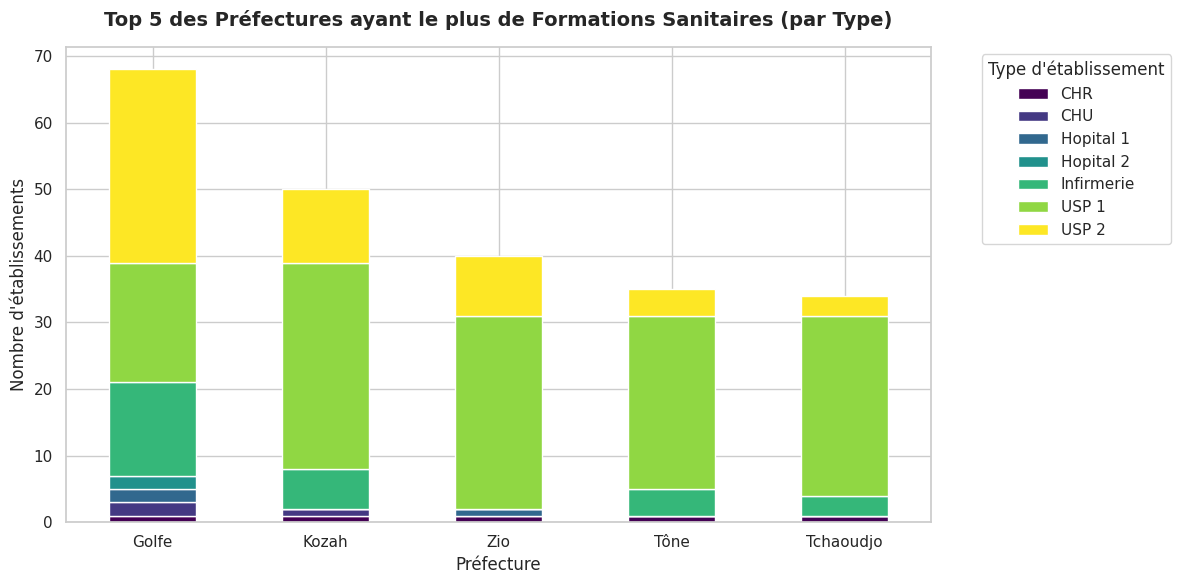

In [25]:
ax = top5_cross.plot(kind='bar', stacked=True, figsize=(12, 6), cmap='viridis')
plt.title("Top 5 des Préfectures ayant le plus de Formations Sanitaires (par Type)", fontsize=14, weight='bold', pad=15)
plt.xlabel("Préfecture", fontsize=12)
plt.ylabel("Nombre d'établissements", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Type d'établissement", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [26]:
# les 5 dernières préfectures
bottom_5_pref = gdf['prefecture_nom_bdd'].value_counts().tail(5)
print("--- Les prefectures ayant les moins de formations sanitaires ---")
print(bottom_5_pref)

--- Les prefectures ayant les moins de formations sanitaires ---
prefecture_nom_bdd
Assoli        8
Mô            7
Moyen-Mono    6
Cinkassé      5
Kpendjal      4
Name: count, dtype: int64


In [27]:
# Filtrer le dataset pour ne garder que ces 5 dernières
df_bottom5 = gdf[gdf['prefecture_nom_bdd'].isin(bottom_5_pref.index)]
bottom5_cross = pd.crosstab(df_bottom5['prefecture_nom_bdd'], df_bottom5['etablissement_type']).loc[bottom_5_pref.index]
print(bottom5_cross)

etablissement_type  Hopital 1  Hopital 2  USP 1  USP 2
prefecture_nom_bdd                                    
Assoli                      1          0      7      0
Mô                          1          0      6      0
Moyen-Mono                  0          1      4      1
Cinkassé                    1          0      3      1
Kpendjal                    1          0      3      0


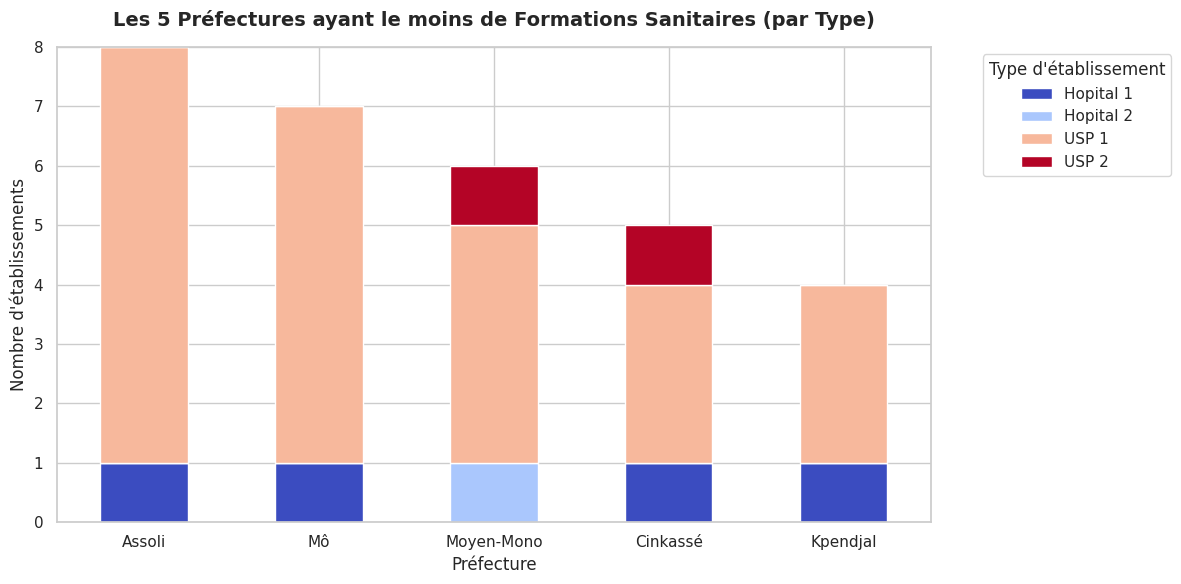

In [28]:
ax = bottom5_cross.plot(kind='bar', stacked=True, figsize=(12, 6), cmap='coolwarm')
plt.title("Les 5 Préfectures ayant le moins de Formations Sanitaires (par Type)", fontsize=14, weight='bold', pad=15)
plt.xlabel("Préfecture", fontsize=12)
plt.ylabel("Nombre d'établissements", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Type d'établissement", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [29]:
# Isolation des données temporelles valides
df_temps = gdf[gdf['annee'].notnull()].copy()
df_temps['annee'] = df_temps['annee'].astype(int)

df_temps.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 675 entries, 2 to 791
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   region_nom_bdd      675 non-null    str     
 1   prefecture_nom_bdd  675 non-null    str     
 2   commune_nom_bdd     675 non-null    str     
 3   canton_nom_bdd      675 non-null    str     
 4   nom_localite        675 non-null    str     
 5   nom_fs              675 non-null    str     
 6   annee               675 non-null    int64   
 7   etablissement_type  675 non-null    str     
 8   services_proposes   675 non-null    str     
 9   geometry            675 non-null    geometry
 10  services_nettoyes   675 non-null    object  
dtypes: geometry(1), int64(1), object(1), str(8)
memory usage: 471.4+ KB


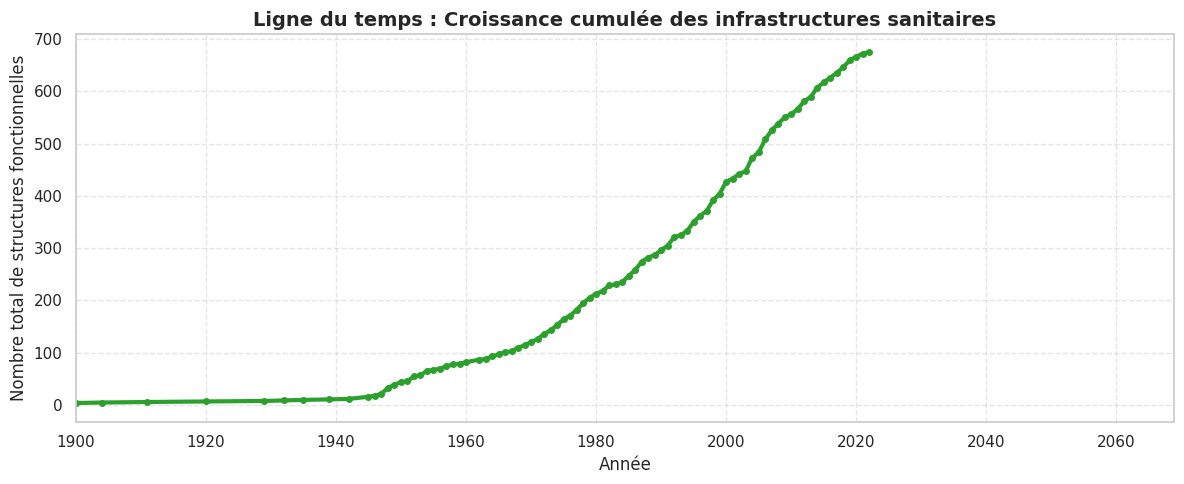

In [30]:
# Creation de décennies pour voir les grandes vagues de construction
df_temps['decennie'] = (df_temps['annee'] // 10) * 10

# Evolution cumulee dans le temps
plt.figure(figsize=(12, 5))
evolution = df_temps['annee'].value_counts().sort_index().cumsum()
plt.plot(evolution.index, evolution.values, color='#2ca02c', linewidth=3, marker='o', markersize=4)
plt.xlim(left=1900)
plt.title("Ligne du temps : Croissance cumulée des infrastructures sanitaires", fontsize=14, weight='bold')
plt.xlabel("Année")
plt.ylabel("Nombre total de structures fonctionnelles")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



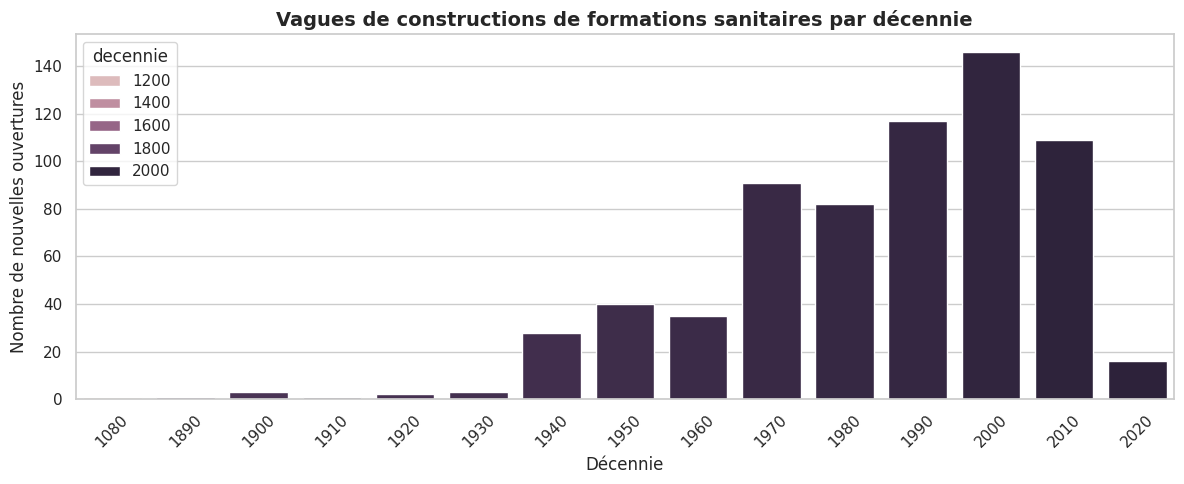

In [31]:
# Zoom par décennie pour identifier les accélérations politiques/historiques
plt.figure(figsize=(12, 5))
sns.countplot(data=df_temps, x='decennie', hue='decennie')
plt.title("Vagues de constructions de formations sanitaires par décennie", fontsize=14, weight='bold')
plt.xlabel("Décennie")
plt.ylabel("Nombre de nouvelles ouvertures")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

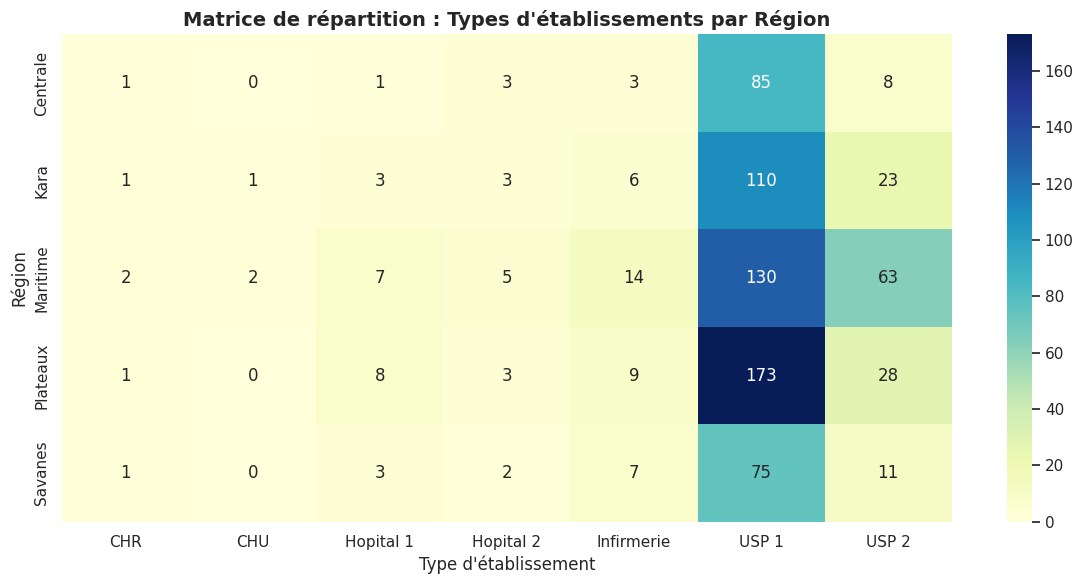

In [32]:
# Régions vs Types d'établissements
cross_tab = pd.crosstab(gdf['region_nom_bdd'], gdf['etablissement_type'])

plt.figure(figsize=(12, 6))
sns.heatmap(cross_tab, annot=True, fmt="d", cmap="YlGnBu", cbar=True)
plt.title("Matrice de répartition : Types d'établissements par Région", fontsize=14, weight='bold')
plt.xlabel("Type d'établissement")
plt.ylabel("Région")
plt.tight_layout()
plt.show()

### Analyse Geospatiale

In [33]:
import folium
from folium.plugins import MarkerCluster

In [34]:
# Centrer la carte 
lat_centre = gdf['geometry'].y.mean()
lon_centre = gdf['geometry'].x.mean()

m = folium.Map(location=[lat_centre, lon_centre], zoom_start=7, tiles="OpenStreetMap")

# Marker
marker_cluster = MarkerCluster().add_to(m)


In [35]:
# Ajouter chaque formation sanitaire sur la carte
for idx, row in gdf.iterrows():
    # Extraction des coordonnées
    lon = row['geometry'].x
    lat = row['geometry'].y
    
    # Création du texte de la bulle d'information en HTML propre
    popup_text = f"""
    <div style="font-family: Arial, sans-serif; width: 200px;">
        <h4 style="color: #2c3e50; margin-bottom: 5px;">{row['nom_fs']}</h4>
        <b>Type :</b> {row['etablissement_type']}<br>
        <b>Région :</b> {row['region_nom_bdd']}<br>
        <b>Préfecture :</b> {row['prefecture_nom_bdd']}<br>
        <b>Canton :</b> {row['canton_nom_bdd']}<br>
        <b>Localité :</b> {row['nom_localite']}<br>
        <b>Année d'ouverture :</b> {int(row['annee']) if pd.notnull(row['annee']) else 'Inconnue'}
    </div>
    """
    
    # Ajout du marqueur au cluster
    folium.Marker(
        location=[lat, lon],
        popup=folium.Popup(popup_text, max_width=250),
        tooltip=row['nom_fs'] 
    ).add_to(marker_cluster)
m

In [36]:
# m.save('carte_fs.html')